In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
data = pd.read_csv("Heart_disease - Heart_disease.csv")
print(data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [12]:
X = data.drop("target", axis=1).values
y = data["target"].values

In [13]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)


In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [15]:
# Convert to tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).view(-1, 1)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val).view(-1, 1)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).view(-1, 1)

In [16]:
model_relu = nn.Sequential(

    nn.Linear(X_train.shape[1], 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32, 16),
    nn.BatchNorm1d(16),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(16, 1),
    nn.Sigmoid()

)

In [17]:
optimizer_relu = optim.Adam(model_relu.parameters(), lr=0.001)
criterion = nn.BCELoss()
scheduler_relu = optim.lr_scheduler.StepLR(
    optimizer_relu,
    step_size=20,
    gamma=0.5
)

In [18]:
train_losses_relu = []
val_losses_relu = []

best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(100):
    # TRAIN
    model_relu.train()
    outputs = model_relu(X_train)
    loss = criterion(outputs, y_train)
    optimizer_relu.zero_grad()
    loss.backward()
    optimizer_relu.step()

    # VALIDATION
    model_relu.eval()
    with torch.no_grad():
        val_outputs = model_relu(X_val)
        val_loss = criterion(val_outputs, y_val)

    train_losses_relu.append(loss.item())
    val_losses_relu.append(val_loss.item())

    print(f"Epoch {epoch+1} | Train: {loss.item():.4f} | Val: {val_loss.item():.4f}")

Epoch 1 | Train: 0.7266 | Val: 0.6799
Epoch 2 | Train: 0.7193 | Val: 0.6791
Epoch 3 | Train: 0.7126 | Val: 0.6780
Epoch 4 | Train: 0.7020 | Val: 0.6768
Epoch 5 | Train: 0.7018 | Val: 0.6754
Epoch 6 | Train: 0.6917 | Val: 0.6741
Epoch 7 | Train: 0.6827 | Val: 0.6725
Epoch 8 | Train: 0.6738 | Val: 0.6706
Epoch 9 | Train: 0.6708 | Val: 0.6687
Epoch 10 | Train: 0.6719 | Val: 0.6666
Epoch 11 | Train: 0.6595 | Val: 0.6642
Epoch 12 | Train: 0.6559 | Val: 0.6618
Epoch 13 | Train: 0.6492 | Val: 0.6590
Epoch 14 | Train: 0.6456 | Val: 0.6562
Epoch 15 | Train: 0.6418 | Val: 0.6532
Epoch 16 | Train: 0.6403 | Val: 0.6502
Epoch 17 | Train: 0.6299 | Val: 0.6471
Epoch 18 | Train: 0.6223 | Val: 0.6439
Epoch 19 | Train: 0.6249 | Val: 0.6403
Epoch 20 | Train: 0.6137 | Val: 0.6367
Epoch 21 | Train: 0.6154 | Val: 0.6333
Epoch 22 | Train: 0.6101 | Val: 0.6297
Epoch 23 | Train: 0.6083 | Val: 0.6260
Epoch 24 | Train: 0.5980 | Val: 0.6223
Epoch 25 | Train: 0.5957 | Val: 0.6184
Epoch 26 | Train: 0.5929 | Val: 0.

In [19]:
    # Scheduler
scheduler_relu.step()

    # Early Stopping
if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model_relu = model_relu.state_dict()

else:
        counter += 1
if counter >= patience:
        print("Early Stopping")


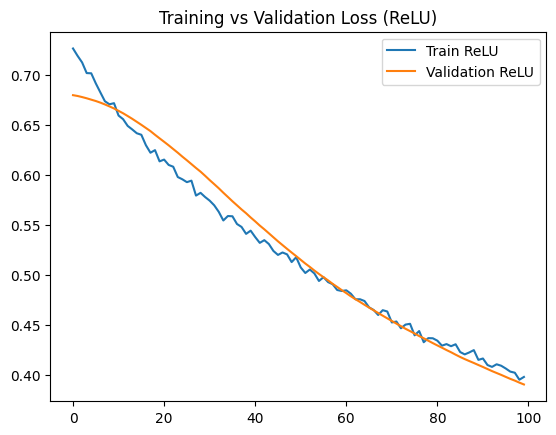

In [20]:
plt.plot(train_losses_relu, label="Train ReLU")
plt.plot(val_losses_relu, label="Validation ReLU")

plt.legend()

plt.title("Training vs Validation Loss (ReLU)")

plt.show()

In [21]:
model_relu.load_state_dict(best_model_relu)

model_relu.eval()

with torch.no_grad():

    predictions = model_relu(X_test)

    predictions = (predictions > 0.5).float()

    accuracy_relu = (predictions == y_test).sum() / y_test.shape[0]

print("ReLU Test Accuracy:", accuracy_relu.item())

ReLU Test Accuracy: 0.915463924407959


In [22]:
model_tanh = nn.Sequential(

    nn.Linear(X_train.shape[1], 32),
    nn.BatchNorm1d(32),
    nn.Tanh(),
    nn.Dropout(0.3),

    nn.Linear(32, 16),
    nn.BatchNorm1d(16),
    nn.Tanh(),
    nn.Dropout(0.3),

    nn.Linear(16, 1),
    nn.Sigmoid()

)

In [23]:
optimizer_tanh = optim.Adam(model_tanh.parameters(), lr=0.001)
criterion = nn.BCELoss()
scheduler_tanh = optim.lr_scheduler.StepLR(
    optimizer_tanh,
    step_size=20,
    gamma=0.5
)


In [24]:
train_losses_tanh = []
val_losses_tanh = []

best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(100):
    # TRAIN
    model_tanh.train()
    outputs = model_tanh(X_train)
    loss = criterion(outputs, y_train)
    optimizer_tanh.zero_grad()
    loss.backward()
    optimizer_tanh.step()

    # VALIDATION
    model_tanh.eval()
    with torch.no_grad():
        val_outputs = model_tanh(X_val)
        val_loss = criterion(val_outputs, y_val)

    train_losses_tanh.append(loss.item())
    val_losses_tanh.append(val_loss.item())

    print(f"Epoch {epoch+1} | Train: {loss.item():.4f} | Val: {val_loss.item():.4f}")

Epoch 1 | Train: 0.8209 | Val: 0.7871
Epoch 2 | Train: 0.8141 | Val: 0.7837
Epoch 3 | Train: 0.8105 | Val: 0.7799
Epoch 4 | Train: 0.8068 | Val: 0.7758
Epoch 5 | Train: 0.8002 | Val: 0.7717
Epoch 6 | Train: 0.8017 | Val: 0.7678
Epoch 7 | Train: 0.7891 | Val: 0.7637
Epoch 8 | Train: 0.7809 | Val: 0.7601
Epoch 9 | Train: 0.7809 | Val: 0.7562
Epoch 10 | Train: 0.7767 | Val: 0.7523
Epoch 11 | Train: 0.7722 | Val: 0.7486
Epoch 12 | Train: 0.7666 | Val: 0.7451
Epoch 13 | Train: 0.7657 | Val: 0.7418
Epoch 14 | Train: 0.7661 | Val: 0.7388
Epoch 15 | Train: 0.7549 | Val: 0.7356
Epoch 16 | Train: 0.7503 | Val: 0.7325
Epoch 17 | Train: 0.7473 | Val: 0.7297
Epoch 18 | Train: 0.7446 | Val: 0.7267
Epoch 19 | Train: 0.7414 | Val: 0.7239
Epoch 20 | Train: 0.7353 | Val: 0.7210
Epoch 21 | Train: 0.7345 | Val: 0.7183
Epoch 22 | Train: 0.7320 | Val: 0.7157
Epoch 23 | Train: 0.7347 | Val: 0.7134
Epoch 24 | Train: 0.7323 | Val: 0.7107
Epoch 25 | Train: 0.7329 | Val: 0.7084
Epoch 26 | Train: 0.7278 | Val: 0.

In [25]:
scheduler_tanh.step()
    # Early Stopping
if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model_tanh = model_tanh.state_dict()
else:
        counter += 1
if counter >= patience:
        print("Early Stopping")
     

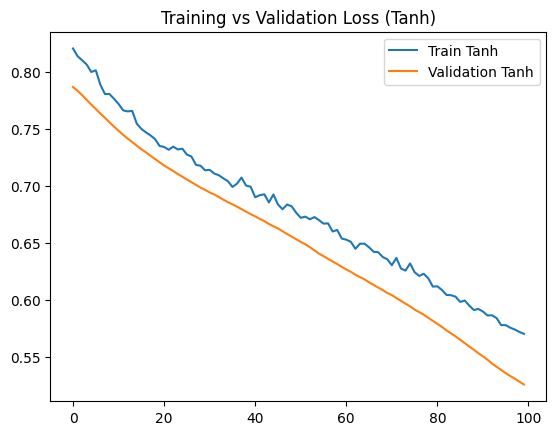

In [26]:
plt.plot(train_losses_tanh, label="Train Tanh")
plt.plot(val_losses_tanh, label="Validation Tanh")
plt.legend()
plt.title("Training vs Validation Loss (Tanh)")
plt.show()

In [27]:
model_tanh.load_state_dict(best_model_tanh)
model_tanh.eval()
with torch.no_grad():
    predictions = model_tanh(X_test)
    predictions = (predictions > 0.5).float()
    accuracy_tanh = (predictions == y_test).sum() / y_test.shape[0]

print("Tanh Test Accuracy:", accuracy_tanh.item())

Tanh Test Accuracy: 0.7680412530899048


In [28]:
print("\nFinal Comparison")
print(f"ReLU Accuracy: {accuracy_relu.item():.4f}")
print(f"Tanh Accuracy: {accuracy_tanh.item():.4f}")


Final Comparison
ReLU Accuracy: 0.9155
Tanh Accuracy: 0.7680


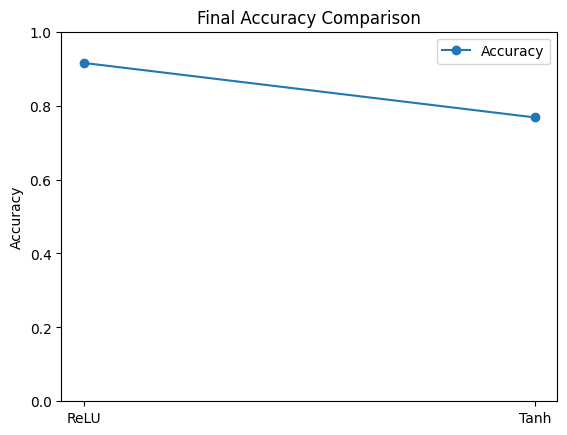

In [29]:
plt.plot([accuracy_relu, accuracy_tanh], marker="o")
plt.xticks([0, 1], ["ReLU", "Tanh"])
plt.title("Final Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend(["Accuracy"])
plt.show()

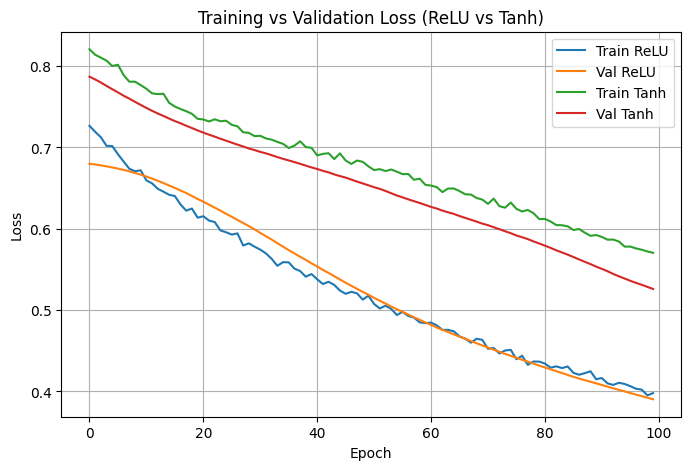

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# ReLU
plt.plot(train_losses_relu, label="Train ReLU")
plt.plot(val_losses_relu, label="Val ReLU")

# Tanh
plt.plot(train_losses_tanh, label="Train Tanh")
plt.plot(val_losses_tanh, label="Val Tanh")

plt.legend()

plt.title("Training vs Validation Loss (ReLU vs Tanh)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

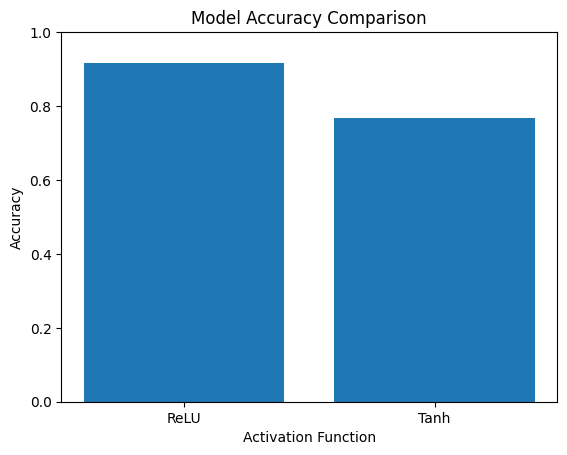

In [34]:
import matplotlib.pyplot as plt

models = ["ReLU", "Tanh"]

accuracies = [
    accuracy_relu.item(),
    accuracy_tanh.item()
]
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Activation Function")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()